# Notebook 3 · Introduction to Monte Carlo Simulation in Financial Risk Management

**Audience:** M.Tech students · Quantitative Finance beginners · BFSI Risk Analysts
**Prerequisites:** Basic probability, statistics, Python
**Environment:** Python 3.11 · NumPy · SciPy · Matplotlib · Pandas

---

## Learning Objectives
1. Master **Geometric Brownian Motion (GBM)** as a model for asset prices.
2. Implement Monte Carlo simulation from scratch with 10,000 paths.
3. Price **European call options** using Monte Carlo and verify with Black-Scholes.
4. Compute **Value-at-Risk (VaR)** at 95% and 99% confidence levels.
5. Compute **Expected Shortfall (ES / CVaR)**.
6. Understand **computational complexity** $O(1/\sqrt{N})$ and why quantum computing is interesting.


## Package Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
from scipy.optimize import brentq
import warnings
warnings.filterwarnings("ignore")

np.random.seed(2024)    # reproducibility

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False})
print("Imports OK.")


Imports OK.


---
## Section 1 · Monte Carlo Fundamentals

### 1.1 What Is Monte Carlo Simulation?

Monte Carlo (MC) simulation is a computational technique that uses **random sampling** to solve problems that are analytically intractable. The name comes from the Casino de Monte Carlo in Monaco.

**Core principle:** For any random variable $X$ with unknown expectation $\mathbb{E}[X]$:

$$\hat{\mathbb{E}}[X] = \frac{1}{N} \sum_{k=1}^N X_k \xrightarrow{N \to \infty} \mathbb{E}[X]$$

by the **Strong Law of Large Numbers**.

### 1.2 Central Limit Theorem — Why MC Works

The estimation error follows:

$$\hat{\mathbb{E}}[X] - \mathbb{E}[X] \sim \mathcal{N}\!\left(0,\, \frac{\sigma_X^2}{N}\right)$$

Therefore the **standard error** is:

$$\varepsilon_N = \frac{\sigma_X}{\sqrt{N}}$$

This is the famous **$O(1/\sqrt{N})$ convergence rate** — to halve the error, you need **4× more samples**.

### 1.3 Applications in Finance

| Application | What MC Simulates |
|---|---|
| Option Pricing | Future asset price paths |
| Value-at-Risk | Portfolio P&L distribution |
| Credit VaR | Default scenarios |
| CVA | Counterparty exposure profiles |
| Stress Testing | Macroeconomic shock scenarios |


---
## Section 2 · Geometric Brownian Motion (GBM)

### 2.1 The Stochastic Differential Equation

Asset prices $S_t$ are commonly modelled by **Geometric Brownian Motion**:

$$\boxed{dS_t = \mu S_t \, dt + \sigma S_t \, dW_t}$$

where:
- $\mu$ = drift (expected annual return, e.g. 8%)
- $\sigma$ = volatility (annual standard deviation, e.g. 20%)
- $W_t$ = Wiener process (Brownian motion): $dW_t = \epsilon\sqrt{dt}$, $\epsilon \sim \mathcal{N}(0,1)$

### 2.2 Closed-Form Solution via Itô's Lemma

Applying **Itô's Lemma** to $f(S_t) = \ln S_t$:

$$d(\ln S_t) = \left(\mu - \frac{\sigma^2}{2}\right) dt + \sigma \, dW_t$$

Integrating from $t=0$ to $t=T$:

$$\ln S_T = \ln S_0 + \left(\mu - \frac{\sigma^2}{2}\right)T + \sigma W_T$$

Therefore:

$$\boxed{S_T = S_0 \exp\!\left[\left(\mu - \frac{\sigma^2}{2}\right)T + \sigma \sqrt{T} \, Z\right], \quad Z \sim \mathcal{N}(0,1)}$$

The $-\sigma^2/2$ term is the **Itô correction** — it ensures $\mathbb{E}[S_T] = S_0 e^{\mu T}$.

### 2.3 Euler-Maruyama Discrete Scheme

For a path with $M$ time steps of size $\Delta t = T/M$:

$$S_{t+\Delta t} = S_t \exp\!\left[\left(\mu - \frac{\sigma^2}{2}\right)\Delta t + \sigma\sqrt{\Delta t}\, Z_t\right]$$


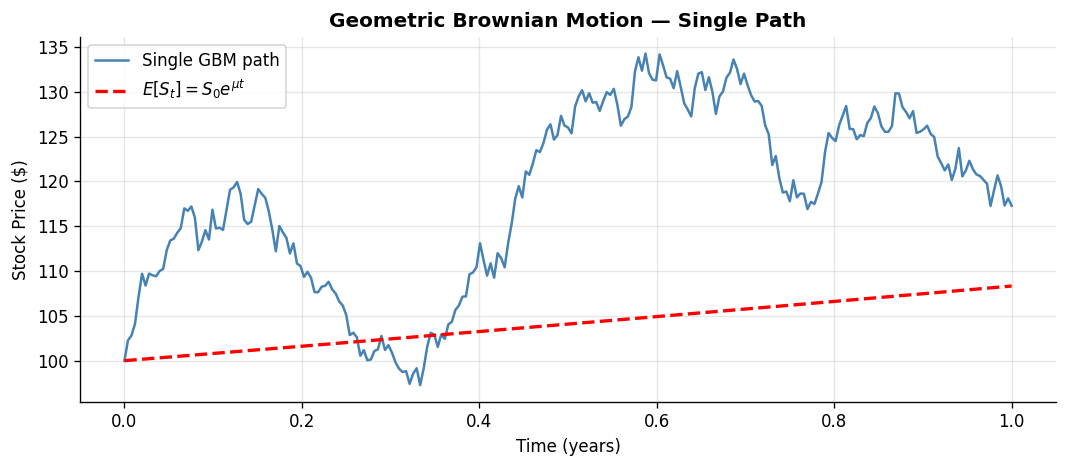

Starting price  : $100.00
Ending price    : $117.28
Analytical E[ST]: $108.33


In [2]:
# ── GBM Parameters ────────────────────────────────────────────────────────
S0    = 100.0     # initial stock price
mu    = 0.08      # annual drift (8%)
sigma = 0.20      # annual volatility (20%)
T     = 1.0       # time horizon (1 year)
M     = 252       # number of time steps (trading days)
dt    = T / M     # time step size

# ── Illustrate single GBM path ────────────────────────────────────────────
np.random.seed(0)
t_grid = np.linspace(0, T, M + 1)
Z_single = np.random.randn(M)

S_path = np.zeros(M + 1)
S_path[0] = S0
for t in range(M):
    # Euler-Maruyama discretisation of GBM
    S_path[t+1] = S_path[t] * np.exp(
        (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z_single[t]
    )

# Analytical mean E[S_t] = S0 * exp(mu * t)
S_mean_analytical = S0 * np.exp(mu * t_grid)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t_grid, S_path, lw=1.5, color="steelblue", label="Single GBM path")
ax.plot(t_grid, S_mean_analytical, lw=2, color="red", ls="--",
        label=r"$E[S_t] = S_0 e^{\mu t}$")
ax.set_xlabel("Time (years)"); ax.set_ylabel("Stock Price ($)")
ax.set_title("Geometric Brownian Motion — Single Path", fontsize=12, fontweight="bold")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Starting price  : ${S0:.2f}")
print(f"Ending price    : ${S_path[-1]:.2f}")
print(f"Analytical E[ST]: ${S_mean_analytical[-1]:.2f}")


---
## Section 3 · Generate 10,000 Simulation Paths

We simulate $N = 10{,}000$ independent GBM paths using **vectorised NumPy** operations.

The trick is to generate all random shocks at once: $Z \in \mathbb{R}^{N \times M}$, then compute cumulative log-returns.


In [3]:
N_SIMS = 10_000     # number of Monte Carlo paths

# ── Vectorised simulation ──────────────────────────────────────────────────
# Z: shape (N_SIMS, M) — all random increments at once
Z = np.random.randn(N_SIMS, M)

# Log-returns for each step: (mu - sigma^2/2)*dt + sigma*sqrt(dt)*Z
log_returns = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z

# Cumulative log-returns, prepend 0 for t=0
log_cum = np.hstack([np.zeros((N_SIMS, 1)), np.cumsum(log_returns, axis=1)])

# Stock prices: S(t) = S0 * exp(cumulative log-return)
S_paths = S0 * np.exp(log_cum)          # shape: (N_SIMS, M+1)

print(f"Simulated {N_SIMS:,} paths × {M+1} time steps")
print(f"S_paths shape: {S_paths.shape}")
print(f"Terminal price stats:")
ST = S_paths[:, -1]
print(f"  Mean     : ${ST.mean():.2f}  (analytical: ${S0*np.exp(mu*T):.2f})")
print(f"  Std Dev  : ${ST.std():.2f}")
print(f"  Min      : ${ST.min():.2f}")
print(f"  Max      : ${ST.max():.2f}")
print(f"  5th pct  : ${np.percentile(ST, 5):.2f}")
print(f"  95th pct : ${np.percentile(ST, 95):.2f}")


Simulated 10,000 paths × 253 time steps
S_paths shape: (10000, 253)
Terminal price stats:
  Mean     : $108.37  (analytical: $108.33)
  Std Dev  : $21.57
  Min      : $47.75
  Max      : $213.80
  5th pct  : $76.96
  95th pct : $147.52


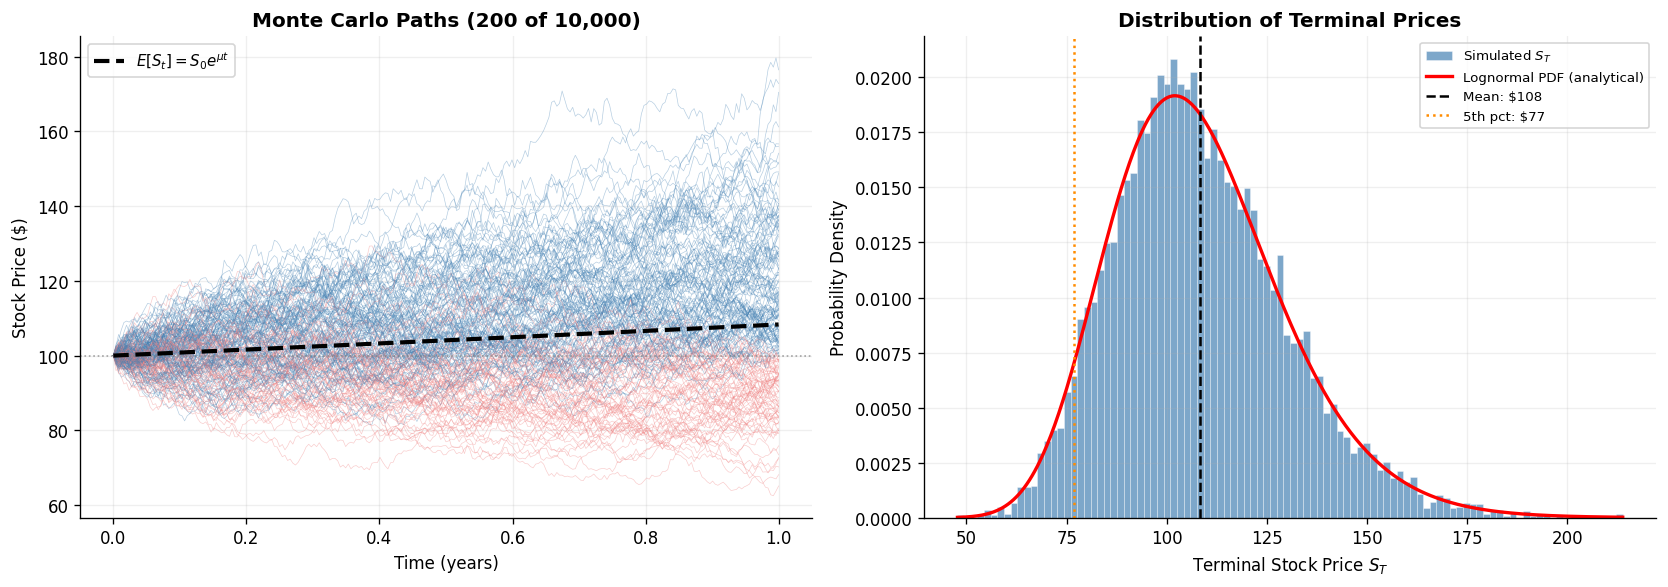

In [4]:
# ── Visualise Monte Carlo paths ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: 200 sample paths
ax1 = axes[0]
sample_idx = np.random.choice(N_SIMS, 200, replace=False)
for idx in sample_idx:
    profit = S_paths[idx, -1] >= S0
    ax1.plot(t_grid, S_paths[idx], lw=0.4,
             color="steelblue" if profit else "lightcoral", alpha=0.4)
ax1.plot(t_grid, S0 * np.exp(mu * t_grid), lw=2.5, color="black",
         ls="--", label=r"$E[S_t] = S_0 e^{\mu t}$", zorder=5)
ax1.axhline(S0, color="gray", lw=1, ls=":", alpha=0.7)
ax1.set_xlabel("Time (years)"); ax1.set_ylabel("Stock Price ($)")
ax1.set_title(f"Monte Carlo Paths (200 of {N_SIMS:,})", fontsize=12, fontweight="bold")
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.2)

# Right: terminal price distribution
ax2 = axes[1]
ax2.hist(ST, bins=100, density=True, color="steelblue", alpha=0.7,
         edgecolor="white", lw=0.3, label="Simulated $S_T$")

# Overlay lognormal analytical PDF
x_range = np.linspace(ST.min(), ST.max(), 500)
log_mean = np.log(S0) + (mu - 0.5 * sigma**2) * T
log_std  = sigma * np.sqrt(T)
pdf_vals = norm.pdf(np.log(x_range), loc=log_mean, scale=log_std) / x_range
ax2.plot(x_range, pdf_vals, "r-", lw=2, label="Lognormal PDF (analytical)")
ax2.axvline(ST.mean(), color="black", lw=1.5, ls="--", label=f"Mean: ${ST.mean():.0f}")
ax2.axvline(np.percentile(ST, 5), color="darkorange", lw=1.5, ls=":",
            label=f"5th pct: ${np.percentile(ST,5):.0f}")

ax2.set_xlabel("Terminal Stock Price $S_T$"); ax2.set_ylabel("Probability Density")
ax2.set_title("Distribution of Terminal Prices", fontsize=12, fontweight="bold")
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()


---
## Section 4 · European Call Option Pricing

### 4.1 Black-Scholes Analytical Formula

For a European call option with strike $K$ and maturity $T$:

$$C_{\text{BS}} = S_0 \Phi(d_1) - K e^{-rT} \Phi(d_2)$$

where:
$$d_1 = \frac{\ln(S_0/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

and $\Phi(\cdot)$ is the standard normal CDF.

### 4.2 Monte Carlo Pricing

Under the risk-neutral measure $\mathbb{Q}$ (replace $\mu$ with $r$):

$$C_{\text{MC}} = e^{-rT} \cdot \frac{1}{N}\sum_{k=1}^N \max(S_T^{(k)} - K, 0)$$

### 4.3 Convergence

The MC error is $O(1/\sqrt{N})$, so to achieve $\varepsilon$ accuracy we need $N \approx \sigma_{\text{payoff}}^2 / \varepsilon^2$ samples.


Black-Scholes price: $8.0214
Monte Carlo price   : $8.0564
MC 95% CI           : [$7.7970, $8.3159]
Absolute error      : $0.0351
Relative error      : 0.437%


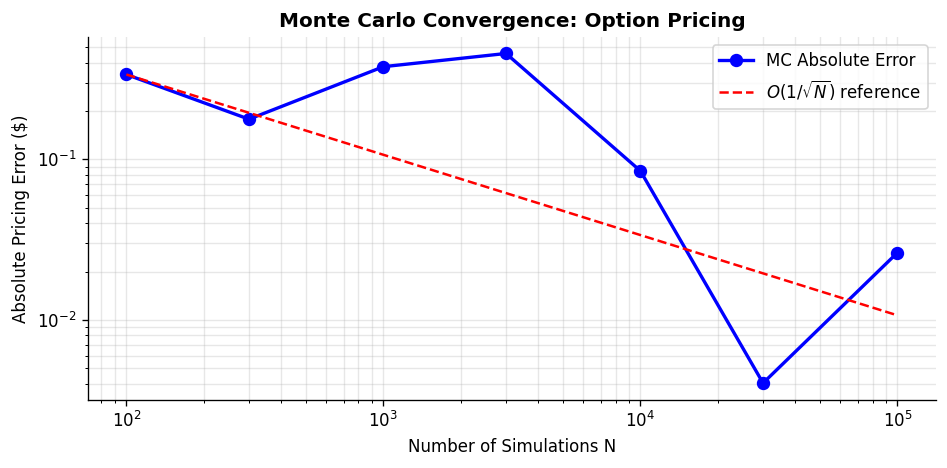

In [5]:
# ── Option parameters ──────────────────────────────────────────────────────
K    = 105.0    # strike price
r    = 0.05     # risk-free rate
# T, sigma, S0, M already defined above

# ── Black-Scholes exact price ─────────────────────────────────────────────
d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)
C_BS = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
print(f"Black-Scholes price: ${C_BS:.4f}")

# ── Monte Carlo under risk-neutral measure ────────────────────────────────
# Re-simulate using r instead of mu for risk-neutral pricing
Z_rn  = np.random.randn(N_SIMS)
ST_rn = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z_rn)

payoffs    = np.maximum(ST_rn - K, 0)
C_MC       = np.exp(-r * T) * payoffs.mean()
C_MC_std   = np.exp(-r * T) * payoffs.std() / np.sqrt(N_SIMS)
C_MC_CI_lo = C_MC - 1.96 * C_MC_std
C_MC_CI_hi = C_MC + 1.96 * C_MC_std

print(f"Monte Carlo price   : ${C_MC:.4f}")
print(f"MC 95% CI           : [${C_MC_CI_lo:.4f}, ${C_MC_CI_hi:.4f}]")
print(f"Absolute error      : ${abs(C_MC - C_BS):.4f}")
print(f"Relative error      : {abs(C_MC - C_BS)/C_BS*100:.3f}%")

# ── Convergence study ─────────────────────────────────────────────────────
N_list = [100, 300, 1000, 3000, 10000, 30000, 100000]
mc_prices  = []
mc_errors  = []

for n in N_list:
    Z_n  = np.random.randn(n)
    ST_n = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z_n)
    pay  = np.maximum(ST_n - K, 0)
    p    = np.exp(-r*T) * pay.mean()
    mc_prices.append(p)
    mc_errors.append(abs(p - C_BS))

# ── Plot convergence ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(N_list, mc_errors, "bo-", lw=2, ms=7, label="MC Absolute Error")
# Plot O(1/sqrt(N)) reference line
ref = mc_errors[0] * np.sqrt(N_list[0]) / np.sqrt(np.array(N_list))
ax.loglog(N_list, ref, "r--", lw=1.5, label=r"$O(1/\sqrt{N})$ reference")
ax.set_xlabel("Number of Simulations N"); ax.set_ylabel("Absolute Pricing Error ($)")
ax.set_title("Monte Carlo Convergence: Option Pricing", fontsize=12, fontweight="bold")
ax.legend(); ax.grid(True, alpha=0.3, which="both")
plt.tight_layout(); plt.show()


---
## Section 5 · Value-at-Risk (VaR)

### 5.1 Definition

**Value-at-Risk at confidence level $\alpha$** is the maximum loss that will not be exceeded with probability $\alpha$:

$$\text{VaR}_\alpha = -\inf\{l : P(L > l) \leq 1-\alpha\} = -q_\alpha(L)$$

Equivalently, $\text{VaR}_\alpha$ is the $-(1-\alpha)$-th quantile of the P&L distribution:

$$P(\text{P\&L} < -\text{VaR}_\alpha) = 1 - \alpha$$

### 5.2 Monte Carlo VaR

1. Simulate $N$ scenarios of portfolio P&L: $\Delta P = S_T - S_0$
2. Sort P&Ls in ascending order
3. $\text{VaR}_{95\%} = -F^{-1}(0.05)$ where $F$ is the empirical CDF

### 5.3 Regulatory Context (Basel III/IV)

Under Basel IV, banks must compute:
- **VaR at 99% (10-day)** for market risk capital
- **Expected Shortfall (ES) at 97.5%** replacing VaR as the primary metric in FRTB


In [6]:
# ── P&L distribution (1-year holding period) ─────────────────────────────
PnL = S_paths[:, -1] - S0          # profit/loss = ST - S0

# ── VaR at 95% and 99% ───────────────────────────────────────────────────
VaR_95 = -np.percentile(PnL, 5)    # 5th percentile of PnL
VaR_99 = -np.percentile(PnL, 1)    # 1st percentile of PnL

print(f"VaR 95%  (1-year): ${VaR_95:.2f}  (lose up to ${VaR_95:.2f} with 95% confidence)")
print(f"VaR 99%  (1-year): ${VaR_99:.2f}  (lose up to ${VaR_99:.2f} with 99% confidence)")
print(f"P(loss > VaR 95%): {(PnL < -VaR_95).mean()*100:.1f}%  (target: 5.0%)")
print(f"P(loss > VaR 99%): {(PnL < -VaR_99).mean()*100:.1f}%  (target: 1.0%)")

# ── Parametric VaR for comparison ─────────────────────────────────────────
# Assume P&L ~ N(mu_PnL, sigma_PnL)
mu_PnL    = PnL.mean()
sigma_PnL = PnL.std()
VaR_95_param = -(mu_PnL + norm.ppf(0.05) * sigma_PnL)
VaR_99_param = -(mu_PnL + norm.ppf(0.01) * sigma_PnL)
print(f"\nParametric VaR 95%: ${VaR_95_param:.2f}")
print(f"Parametric VaR 99%: ${VaR_99_param:.2f}")
print("(Parametric assumes normality; MC captures fat tails of lognormal)")


VaR 95%  (1-year): $23.04  (lose up to $23.04 with 95% confidence)
VaR 99%  (1-year): $32.69  (lose up to $32.69 with 99% confidence)
P(loss > VaR 95%): 5.0%  (target: 5.0%)
P(loss > VaR 99%): 1.0%  (target: 1.0%)

Parametric VaR 95%: $27.10
Parametric VaR 99%: $41.80
(Parametric assumes normality; MC captures fat tails of lognormal)


---
## Section 6 · Expected Shortfall (ES / CVaR)

### 6.1 Definition

**Expected Shortfall** (also called **Conditional VaR** or **CVaR**) measures the **average loss** in the worst $(1-\alpha)$ scenarios:

$$\text{ES}_\alpha = -\mathbb{E}\!\left[L \;\middle|\; L > \text{VaR}_\alpha\right] = -\frac{1}{1-\alpha}\int_0^{1-\alpha} q_u(L)\, du$$

### 6.2 Why ES > VaR?

- VaR only tells us "the threshold" but nothing about losses **beyond** that threshold.
- ES captures **tail risk** — the average loss in stress scenarios.
- Basel IV / FRTB replaced VaR with ES at 97.5% as the primary risk metric.

### 6.3 Example Intuition

If $\text{VaR}_{99\%} = \$20$ and $\text{ES}_{99\%} = \$35$:
- We are 99% confident losses won't exceed $20.
- But **if** they do (1% of the time), the expected loss is $35.


Expected Shortfall 95% : $29.20
Expected Shortfall 99% : $37.47
VaR 95%                : $23.04  (ES > VaR as expected)
VaR 99%                : $32.69
ES/VaR ratio at 95%    : 1.267
ES/VaR ratio at 99%    : 1.146


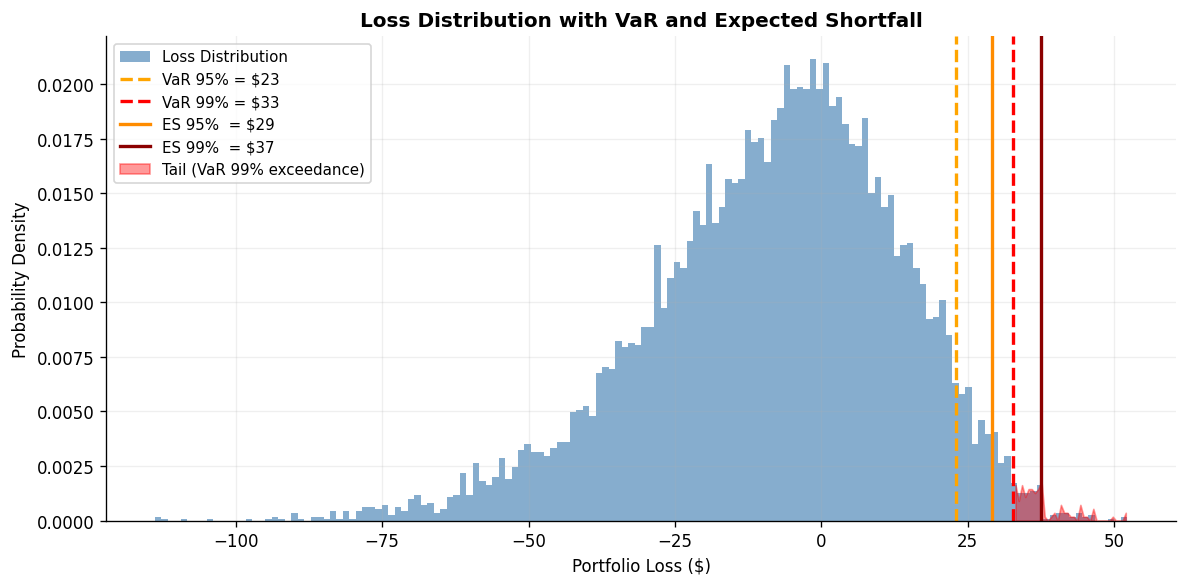

In [7]:
def expected_shortfall(pnl_array, alpha):
    # ES_alpha = -E[L | L < -VaR_alpha]
    # i.e., mean of losses in the worst (1-alpha) tail
    threshold = np.percentile(pnl_array, (1 - alpha) * 100)
    tail_losses = pnl_array[pnl_array <= threshold]
    return -tail_losses.mean()

ES_95 = expected_shortfall(PnL, 0.95)
ES_99 = expected_shortfall(PnL, 0.99)

print(f"Expected Shortfall 95% : ${ES_95:.2f}")
print(f"Expected Shortfall 99% : ${ES_99:.2f}")
print(f"VaR 95%                : ${VaR_95:.2f}  (ES > VaR as expected)")
print(f"VaR 99%                : ${VaR_99:.2f}")
print(f"ES/VaR ratio at 95%    : {ES_95/VaR_95:.3f}")
print(f"ES/VaR ratio at 99%    : {ES_99/VaR_99:.3f}")

# ── Visualise loss distribution with risk metrics ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(-PnL, bins=150, density=True, color="steelblue", alpha=0.65,
        edgecolor="none", label="Loss Distribution")
ax.axvline(VaR_95, color="orange",  lw=2, ls="--", label=f"VaR 95% = ${VaR_95:.0f}")
ax.axvline(VaR_99, color="red",     lw=2, ls="--", label=f"VaR 99% = ${VaR_99:.0f}")
ax.axvline(ES_95,  color="darkorange",  lw=2, ls="-", label=f"ES 95%  = ${ES_95:.0f}")
ax.axvline(ES_99,  color="darkred",     lw=2, ls="-", label=f"ES 99%  = ${ES_99:.0f}")

# Shade tail
x_tail = np.linspace(VaR_99, (-PnL).max(), 200)
# approximate density from histogram
hist_vals, bin_edges = np.histogram(-PnL, bins=300, density=True)
bin_mids = 0.5*(bin_edges[:-1]+bin_edges[1:])
ax.fill_between(bin_mids[bin_mids>VaR_99],
                hist_vals[bin_mids>VaR_99], alpha=0.4,
                color="red", label="Tail (VaR 99% exceedance)")

ax.set_xlabel("Portfolio Loss ($)"); ax.set_ylabel("Probability Density")
ax.set_title("Loss Distribution with VaR and Expected Shortfall", fontsize=12, fontweight="bold")
ax.legend(fontsize=9); ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()


---
## Section 7 · Credit Exposure Example (Simplified CVA)

### 7.1 Credit Valuation Adjustment (CVA)

CVA is the market value of counterparty credit risk on a derivatives position:

$$\text{CVA} \approx (1 - R) \int_0^T \text{EE}(t) \cdot \lambda(t) \cdot D(0,t) \, dt$$

where:
- $R$ = recovery rate (e.g. 40%)
- $\text{EE}(t)$ = **Expected Exposure** at time $t$: $\mathbb{E}[\max(V_t, 0)]$
- $\lambda(t)$ = default intensity (hazard rate)
- $D(0,t) = e^{-rt}$ = discount factor

### 7.2 Monte Carlo CVA

We simulate the mark-to-market value $V_t$ of a forward contract over multiple time steps and compute EE along each path.


CVA estimate: $0.0298
(Counterparty default risk on a 1-year forward)


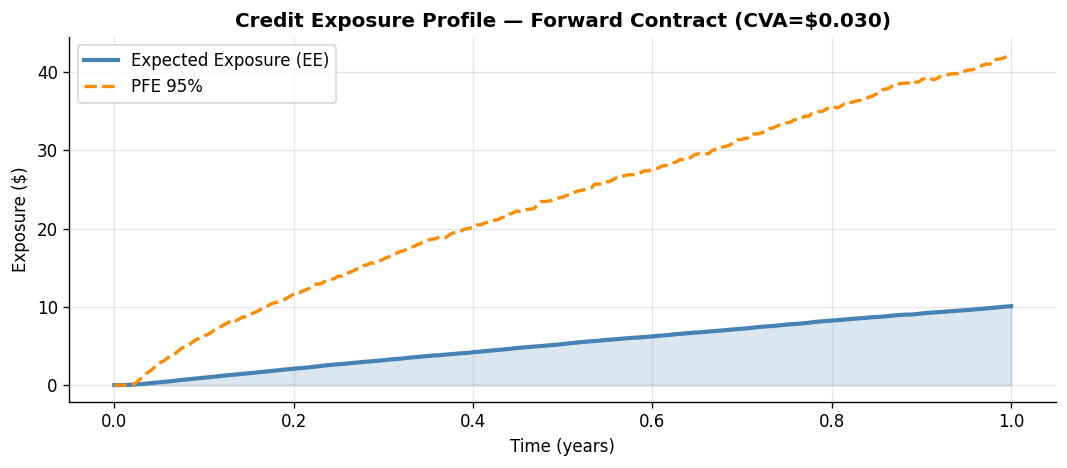

In [8]:
# ── Simplified credit exposure for a forward contract ─────────────────────
# Forward: agree to buy 1 share at forward price F = S0*exp(r*T) at T=1yr
# MtM value at time t: V(t) = S(t)*exp(-r*(T-t)) - F*exp(-r*(T-t))
#                            = exp(-r*(T-t)) * (S(t) - F)

F_fwd   = S0 * np.exp(r * T)    # fair forward price
t_steps = np.linspace(0, T, M + 1)

# Compute MtM value along all simulated paths (S_paths already computed)
discount_t = np.exp(-r * (T - t_steps))         # shape (M+1,)
MtM_paths  = S_paths * discount_t - F_fwd * discount_t   # shape (N_SIMS, M+1)

# Expected Exposure (EE): average of max(V_t, 0) over scenarios
EE = np.mean(np.maximum(MtM_paths, 0), axis=0)  # shape (M+1,)

# Potential Future Exposure (PFE at 95%)
PFE_95 = np.percentile(np.maximum(MtM_paths, 0), 95, axis=0)

# ── Simple CVA approximation ──────────────────────────────────────────────
lambda_haz = 0.01    # hazard rate (1% annual default intensity)
R_rec      = 0.40    # recovery rate

# Riemann sum approximation
dt_cva   = T / M
discount = np.exp(-r * t_steps)
CVA = (1 - R_rec) * np.sum(EE[:-1] * lambda_haz * discount[:-1] * dt_cva)
print(f"CVA estimate: ${CVA:.4f}")
print(f"(Counterparty default risk on a 1-year forward)")

# ── Plot EE and PFE profile ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t_steps, EE,    lw=2.5, color="steelblue", label="Expected Exposure (EE)")
ax.plot(t_steps, PFE_95, lw=2,  color="darkorange", ls="--", label="PFE 95%")
ax.fill_between(t_steps, 0, EE, alpha=0.2, color="steelblue")
ax.set_xlabel("Time (years)"); ax.set_ylabel("Exposure ($)")
ax.set_title(f"Credit Exposure Profile — Forward Contract (CVA=${CVA:.3f})",
             fontsize=12, fontweight="bold")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


---
## Section 8 · Summary Visualisations Dashboard


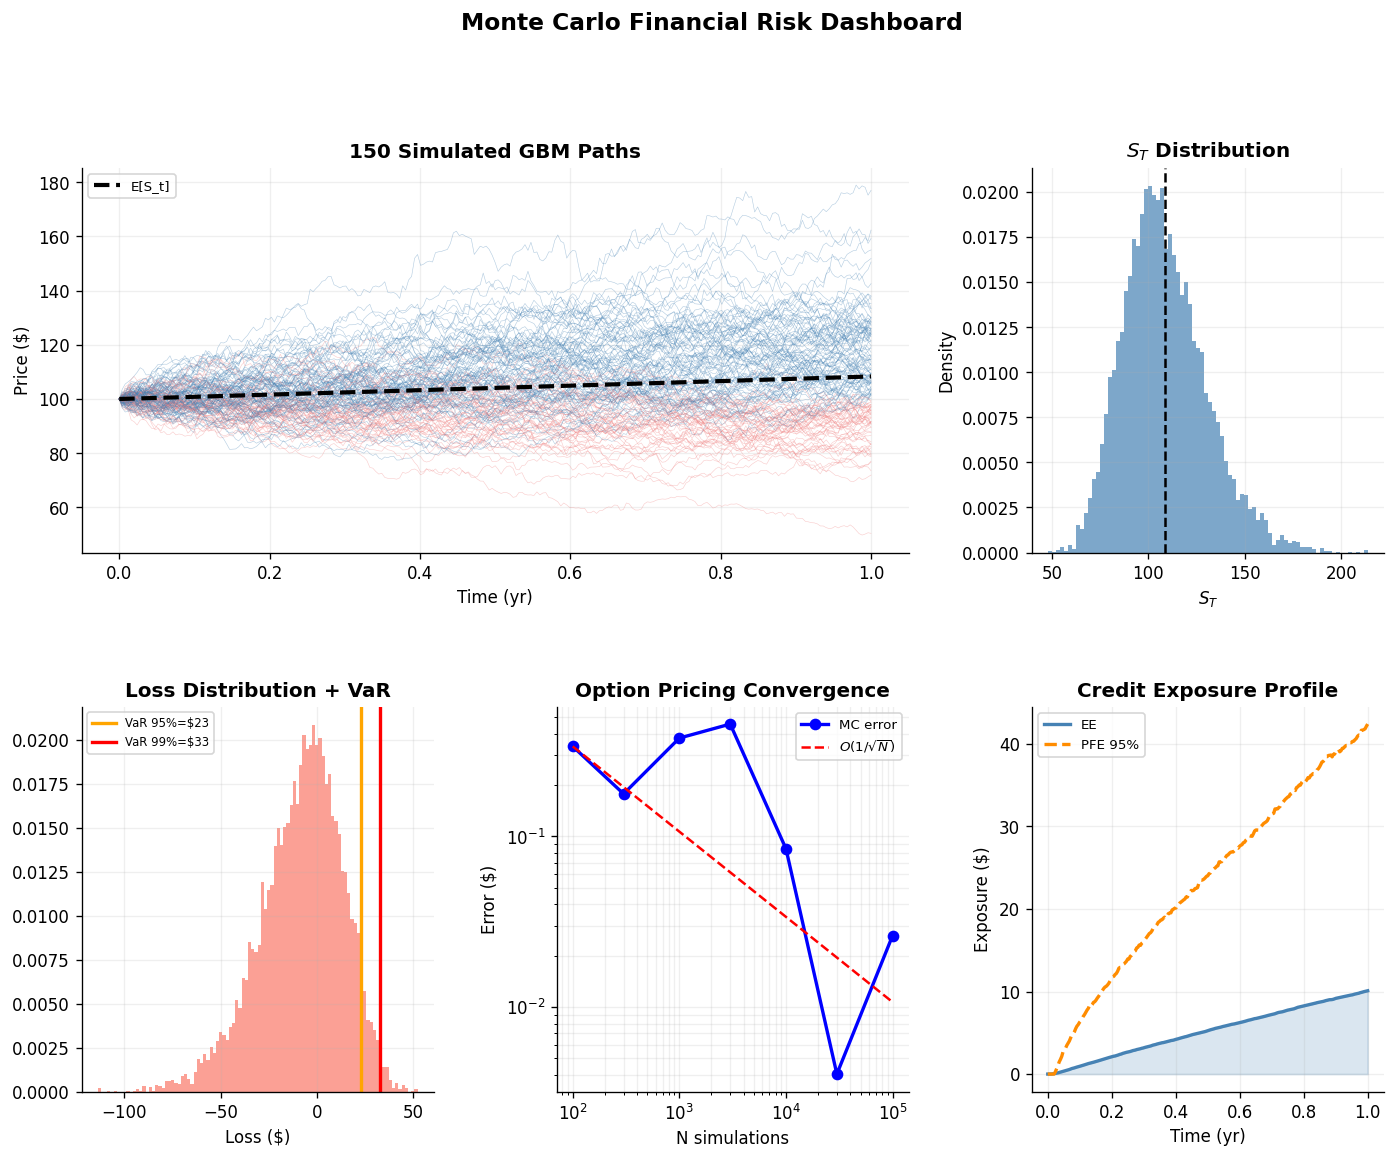

In [9]:
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── 1. MC paths (sample) ───────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
for idx in np.random.choice(N_SIMS, 150, replace=False):
    ax1.plot(t_grid, S_paths[idx], lw=0.35, alpha=0.4,
             color="steelblue" if S_paths[idx,-1]>S0 else "lightcoral")
ax1.plot(t_grid, S0*np.exp(mu*t_grid), lw=2.5, color="black", ls="--",
         label="E[S_t]")
ax1.set_title("150 Simulated GBM Paths", fontweight="bold")
ax1.set_xlabel("Time (yr)"); ax1.set_ylabel("Price ($)")
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.2)

# ── 2. Terminal distribution ───────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.hist(ST, bins=80, density=True, color="steelblue", alpha=0.7, edgecolor="none")
ax2.axvline(ST.mean(), color="black", lw=1.5, ls="--")
ax2.set_title("$S_T$ Distribution", fontweight="bold")
ax2.set_xlabel("$S_T$"); ax2.set_ylabel("Density")
ax2.grid(True, alpha=0.2)

# ── 3. Loss distribution + VaR ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(-PnL, bins=100, density=True, color="salmon", alpha=0.75, edgecolor="none")
ax3.axvline(VaR_95, color="orange", lw=2, label=f"VaR 95%=${VaR_95:.0f}")
ax3.axvline(VaR_99, color="red",    lw=2, label=f"VaR 99%=${VaR_99:.0f}")
ax3.set_title("Loss Distribution + VaR", fontweight="bold")
ax3.set_xlabel("Loss ($)"); ax3.legend(fontsize=7)
ax3.grid(True, alpha=0.2)

# ── 4. MC option pricing convergence ──────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.loglog(N_list, mc_errors, "bo-", lw=2, ms=6, label="MC error")
ref2 = mc_errors[0]*np.sqrt(N_list[0])/np.sqrt(np.array(N_list))
ax4.loglog(N_list, ref2, "r--", lw=1.5, label=r"$O(1/\sqrt{N})$")
ax4.set_title("Option Pricing Convergence", fontweight="bold")
ax4.set_xlabel("N simulations"); ax4.set_ylabel("Error ($)")
ax4.legend(fontsize=8); ax4.grid(True, alpha=0.2, which="both")

# ── 5. EE / PFE profile ───────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.plot(t_steps, EE,    lw=2, color="steelblue", label="EE")
ax5.plot(t_steps, PFE_95, lw=2, color="darkorange", ls="--", label="PFE 95%")
ax5.fill_between(t_steps, 0, EE, alpha=0.2, color="steelblue")
ax5.set_title("Credit Exposure Profile", fontweight="bold")
ax5.set_xlabel("Time (yr)"); ax5.set_ylabel("Exposure ($)")
ax5.legend(fontsize=8); ax5.grid(True, alpha=0.2)

fig.suptitle("Monte Carlo Financial Risk Dashboard", fontsize=14, fontweight="bold", y=1.01)
plt.savefig("mc_dashboard.png", dpi=120, bbox_inches="tight")
plt.show()


---
## Section 9 · Computational Complexity Analysis

### 9.1 MC Convergence Rate

The **Root Mean Squared Error (RMSE)** of a Monte Carlo estimator satisfies:

$$\text{RMSE} = \frac{\sigma}{\sqrt{N}} \propto N^{-1/2}$$

This means:

| To achieve accuracy $\varepsilon$ | Need samples $N$ |
|---|---|
| 10% | 100 |
| 1% | 10,000 |
| 0.1% | 1,000,000 |
| 0.01% | 100,000,000 |

### 9.2 Computational Cost

Total cost = $N \times M$ operations where $M$ = number of time steps per path.

For a realistic bank-wide CVA with $10^6$ paths, $M = 252$ steps, and $500$ counterparties:

$$\text{Cost} = 10^6 \times 252 \times 500 = 1.26 \times 10^{11} \text{ operations}$$

This takes **hours on a modern server cluster** — motivating quantum acceleration.


Fitted exponent: -0.559  (theoretical: -0.500)


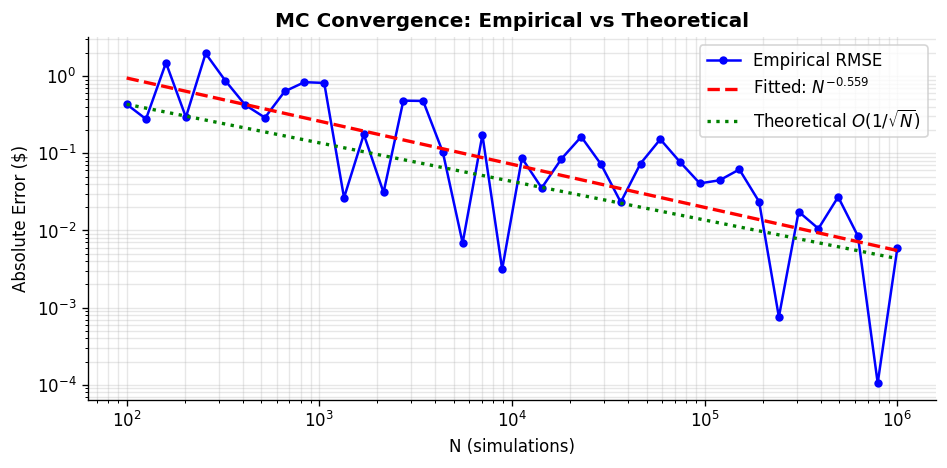


Wall-clock timing (European call MC pricing):
  N=     1,000:      0.09 ms
  N=    10,000:      0.23 ms
  N=   100,000:      1.81 ms
  N= 1,000,000:     19.64 ms


In [10]:
# ── Empirical convergence measurement ─────────────────────────────────────
N_range  = np.logspace(2, 6, 40).astype(int)
true_val = C_BS    # use BS price as ground truth

np.random.seed(99)
mc_rmse = []
for n in N_range:
    Z_n   = np.random.randn(n)
    ST_n  = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z_n)
    c_n   = np.exp(-r*T) * np.maximum(ST_n - K, 0).mean()
    mc_rmse.append(abs(c_n - true_val))

# Fit O(1/sqrt(N)) line
coeffs = np.polyfit(np.log(N_range), np.log(np.array(mc_rmse) + 1e-10), 1)
print(f"Fitted exponent: {coeffs[0]:.3f}  (theoretical: -0.500)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(N_range, mc_rmse, "b-o", ms=4, lw=1.5, label="Empirical RMSE")
ax.loglog(N_range, np.exp(coeffs[1]) * N_range**coeffs[0], "r--",
          lw=2, label=f"Fitted: $N^{{{coeffs[0]:.3f}}}$")
ax.loglog(N_range, mc_rmse[0] * np.sqrt(N_range[0]/N_range), "g:",
          lw=2, label=r"Theoretical $O(1/\sqrt{N})$")
ax.set_xlabel("N (simulations)"); ax.set_ylabel("Absolute Error ($)")
ax.set_title("MC Convergence: Empirical vs Theoretical", fontsize=12, fontweight="bold")
ax.legend(); ax.grid(True, alpha=0.3, which="both")
plt.tight_layout(); plt.show()

# ── Wall-clock timing ──────────────────────────────────────────────────────
import time
sizes = [1_000, 10_000, 100_000, 1_000_000]
times = []
for n in sizes:
    t0 = time.perf_counter()
    Z_t  = np.random.randn(n)
    ST_t = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z_t)
    _    = np.exp(-r*T) * np.maximum(ST_t - K, 0).mean()
    times.append(time.perf_counter() - t0)

print("\nWall-clock timing (European call MC pricing):")
for n, t in zip(sizes, times):
    print(f"  N={n:>10,}:  {t*1000:8.2f} ms")


---
## Section 10 · Why Quantum Computing Is Interesting for Monte Carlo

### 10.1 The $O(1/\sqrt{N})$ Barrier

Classical MC is fundamentally limited by:

$$\varepsilon_{\text{classical}} \propto \frac{1}{\sqrt{N}}$$

**No classical algorithm can break this barrier** for general integration problems (lower bound result).

### 10.2 Quantum Amplitude Estimation (QAE)

Quantum computing can achieve:

$$\varepsilon_{\text{quantum}} \propto \frac{1}{N}$$

This is a **quadratic speedup**: the same accuracy requires only $\sqrt{N_{\text{classical}}}$ quantum circuit evaluations.

| Accuracy $\varepsilon$ | Classical $N_{\text{MC}}$ | Quantum $N_{\text{QAE}}$ | Speedup |
|---|---|---|---|
| $10^{-2}$ | $10^4$ | $100$ | 100× |
| $10^{-3}$ | $10^6$ | $1,000$ | 1,000× |
| $10^{-4}$ | $10^8$ | $10,000$ | 10,000× |

### 10.3 How QAE Works (Preview — see Notebook 2_2)

1. **Encode** the probability distribution into a quantum state $|\psi\rangle = \sqrt{1-a}|0\rangle + \sqrt{a}|1\rangle$
2. **Estimate** $a$ (the amplitude = expected payoff) using quantum phase estimation
3. **Extract** the answer with $O(1/\varepsilon)$ Grover-like oracle calls

### 10.4 Financial Impact

| Use Case | Classical Runtime | Quantum Runtime | Benefit |
|---|---|---|---|
| CVA (500 counterparties) | 8 hours | ~30 seconds | Real-time risk |
| VaR (full revaluation) | Overnight | Minutes | Intraday updates |
| Options book pricing | Hours | Minutes | Faster trading |

> **Disclaimer:** These are projections for fault-tolerant quantum computers (est. 2030+). Current NISQ devices require error mitigation and are limited to small problem sizes.


---
## Section 11 · Interview Questions & Answers

**Q1. Why does Monte Carlo converge as $1/\sqrt{N}$?**
**A:** By the Central Limit Theorem, the sample mean of $N$ i.i.d. random variables has standard deviation $\sigma/\sqrt{N}$. This is a fundamental statistical result, not a limitation of implementation.

**Q2. What is the difference between VaR and Expected Shortfall?**
**A:** VaR gives a loss threshold not exceeded with probability $\alpha$. ES (CVaR) gives the average loss **conditional on** exceeding VaR. ES is more informative about tail risk and is sub-additive (satisfies coherent risk measure axioms), while VaR is not sub-additive in general.

**Q3. What is the Itô correction term $-\sigma^2/2$ in GBM?**
**A:** It ensures the expectation $\mathbb{E}[S_T] = S_0 e^{\mu T}$. Without it, the log-return would have the wrong mean due to Jensen's inequality ($\mathbb{E}[e^X] > e^{\mathbb{E}[X]}$ for non-degenerate $X$).

**Q4. How is CVA computed using Monte Carlo?**
**A:** Simulate portfolio MtM values along multiple paths. At each time step, compute Expected Exposure $\text{EE}(t) = \mathbb{E}[\max(V_t,0)]$. Then integrate $\text{CVA} \approx (1-R)\int_0^T \text{EE}(t)\lambda(t)D(0,t)dt$ via a Riemann sum.

**Q5. Why is Quantum Amplitude Estimation faster than classical MC?**
**A:** QAE uses quantum superposition to effectively evaluate all scenarios simultaneously via amplitude encoding, then extracts the answer using quantum phase estimation. This gives $O(1/N)$ convergence vs $O(1/\sqrt{N})$ classically — a quadratic speedup.

**Q6. What are variance reduction techniques for MC?**
**A:** (1) **Antithetic variates**: use $Z$ and $-Z$ pairs. (2) **Control variates**: use a correlated quantity with known expectation. (3) **Importance sampling**: sample from a tilted distribution. (4) **Quasi-MC (Sobol sequences)**: use low-discrepancy sequences instead of pseudo-random numbers.


---
## Section 12 · References

1. Glasserman, P. (2003). *Monte Carlo Methods in Financial Engineering*. Springer.
2. Hull, J. (2021). *Options, Futures, and Other Derivatives* (11th ed.). Pearson.
3. Stamatopoulos, N. et al. (2020). *Option pricing using quantum computers*. Quantum, 4, 291.
4. Woerner, S. & Egger, D. J. (2019). *Quantum risk analysis*. npj Quantum Information, 5, 15.
5. Basel Committee on Banking Supervision (2019). *Minimum Capital Requirements for Market Risk*.
6. Brigo, D. & Mercurio, F. (2006). *Interest Rate Models — Theory and Practice*. Springer.

## Section 13 · Future Improvements

- Implement antithetic variates and control variates to reduce MC variance.
- Add multi-asset correlated GBM for portfolio VaR.
- Implement Heston stochastic volatility model.
- Add LIBOR Market Model (LMM) for interest rate derivatives.
- Connect to Notebook 2_2 for quantum acceleration via QAE.
